## 08. Reproduce the 2010 paper
**12 April 2025 by MiniUFO**

---
[TOC]

---
### 1. Introduction
Here we reproduce results from several papers on relative dispersion.  In this notebook, we are going to reproduce the PDF plot in LaCasece (2010, the Journal of Marine Research is no longer available now, so no link is provided).  Since we don't have his observations, only the analytical curves are reproduced.

---

### 2. Calculation
#### 2.1 Reproduce Figure 3 in LaCasce (2010) JMR paper

In [69]:
import numpy as np
import xarray as xr
import warnings
import sys
warnings.filterwarnings("ignore")
sys.path.append('../../../')
from xdispersion import ana_PDF, gen_rbins

alpha = 1.1
tbin = np.linspace(0, 25, 251)
tbin = xr.DataArray(tbin, dims='rtime', coords={'rtime':tbin})
rbin = gen_rbins(1e-2, 15000, alpha=alpha)

lund1 = ana_PDF(rbin, tbin, params={'r0':50, 'T':4}, regime='lundgren') * 2 * np.pi * rbin
lund2 = ana_PDF(rbin, tbin, params={'r0':77, 'T':4}, regime='lundgren') * 2 * np.pi * rbin
rich  = ana_PDF(rbin, tbin, params={'r0':50, 'beta':3.9e4*3.1e2**(2/3)/86400}, regime='richardson') * 2 * np.pi * rbin
rayl1 = ana_PDF(rbin, tbin, params={'r0':50, 'k2':2e5}, regime='rayleigh-a') * 2 * np.pi * rbin
rayl2 = ana_PDF(rbin, tbin, params={'r0':50, 'k2':5e5}, regime='rayleigh-a') * 2 * np.pi * rbin

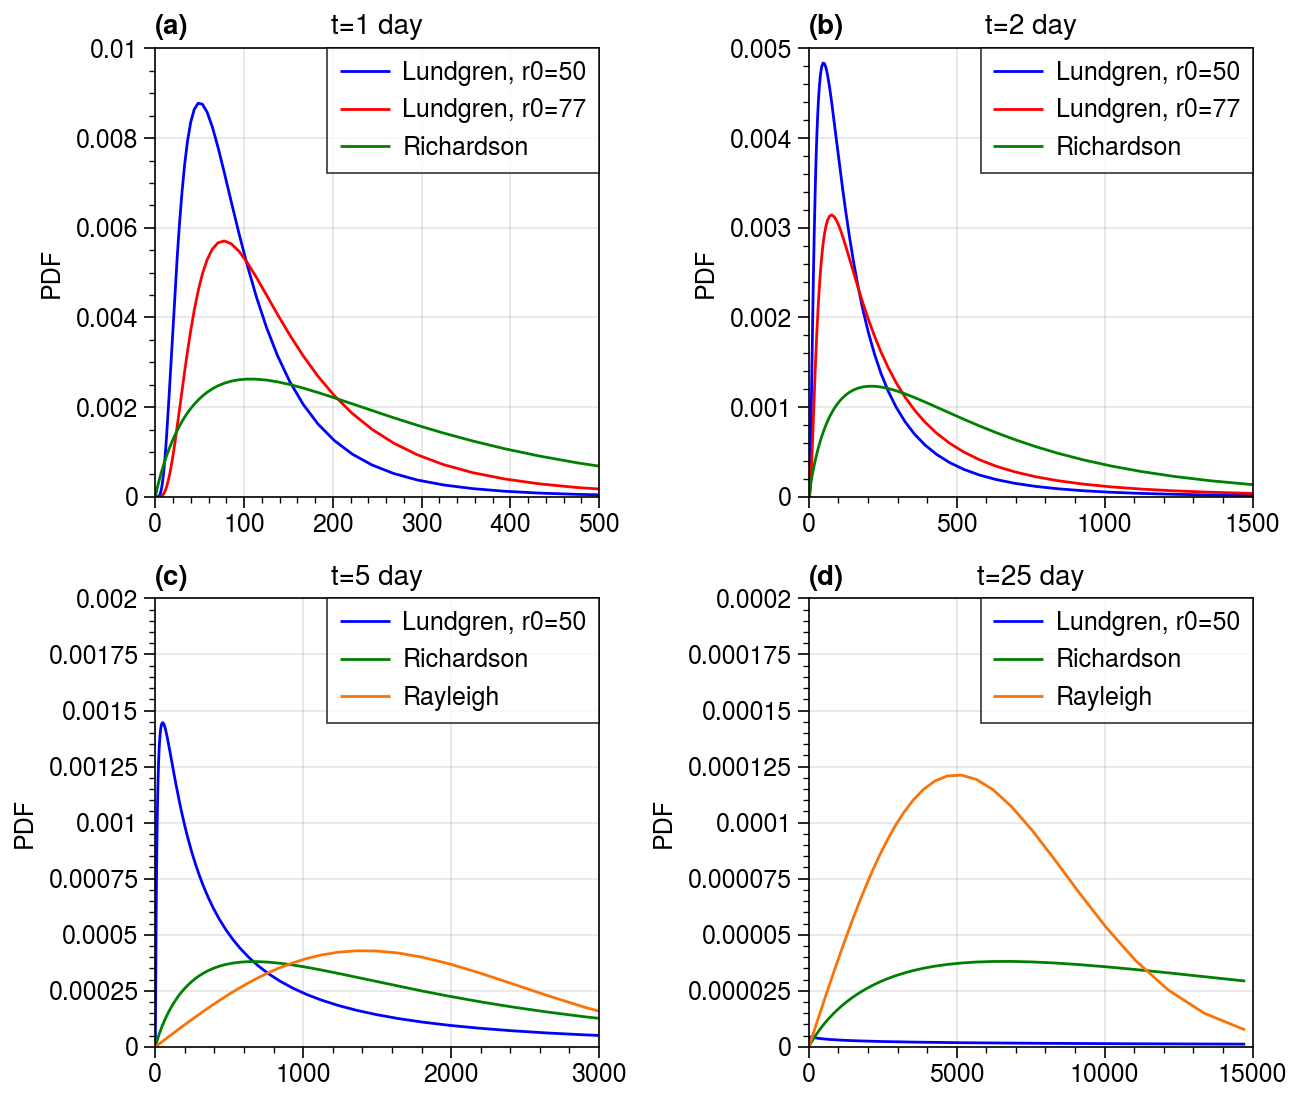

In [70]:
import proplot as pplt
from xdispersion import panel

fig, axes = pplt.subplots(nrows=2, ncols=2, figsize=(6.5, 5.5), facecolor='w',
                          sharex=0, sharey=0)

v1 = {'var':lund1.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=50', 'lw':1, 'color':'b'}
v2 = {'var':lund2.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=77', 'lw':1, 'color':'r'}
v3 = {'var':rich .sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
ax = panel(axes[0,0], [v1,v2,v3],[], title='t=1 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.01], xlim=[0, 500], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=50', 'lw':1, 'color':'b'}
v2 = {'var':lund2.sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=77', 'lw':1, 'color':'r'}
v3 = {'var':rich .sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
ax = panel(axes[0,1], [v1,v2,v3],[], title='t=2 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.005], xlim=[0, 1500], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=50', 'lw':1, 'color':'b'}
v3 = {'var':rich .sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v4 = {'var':rayl1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[1,0], [v1,v3,v4],[], title='t=5 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.002], xlim=[0, 3000], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=25), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=50', 'lw':1, 'color':'b'}
v3 = {'var':rich .sel(rtime=25), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v4 = {'var':rayl2.sel(rtime=25), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[1,1], [v1,v3,v4],[], title='t=25 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 2e-4], xlim=[0, 15000], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
axes.format(abc='(a)')

#### 2.2 Reproduce the Figure 4

In [83]:
lund1 = ana_PDF(rbin, tbin, params={'r0':57, 'T':4}, regime='lundgren') * 2 * np.pi * rbin
lund2 = ana_PDF(rbin, tbin, params={'r0':25, 'T':4}, regime='lundgren') * 2 * np.pi * rbin
rich  = ana_PDF(rbin, tbin, params={'r0':25, 'beta':3.9e4*3.1e2**(2/3)/86400}, regime='richardson') * 2 * np.pi * rbin
rayl1 = ana_PDF(rbin, tbin, params={'r0':25, 'k2':1.4e5}, regime='rayleigh-a') * 2 * np.pi * rbin

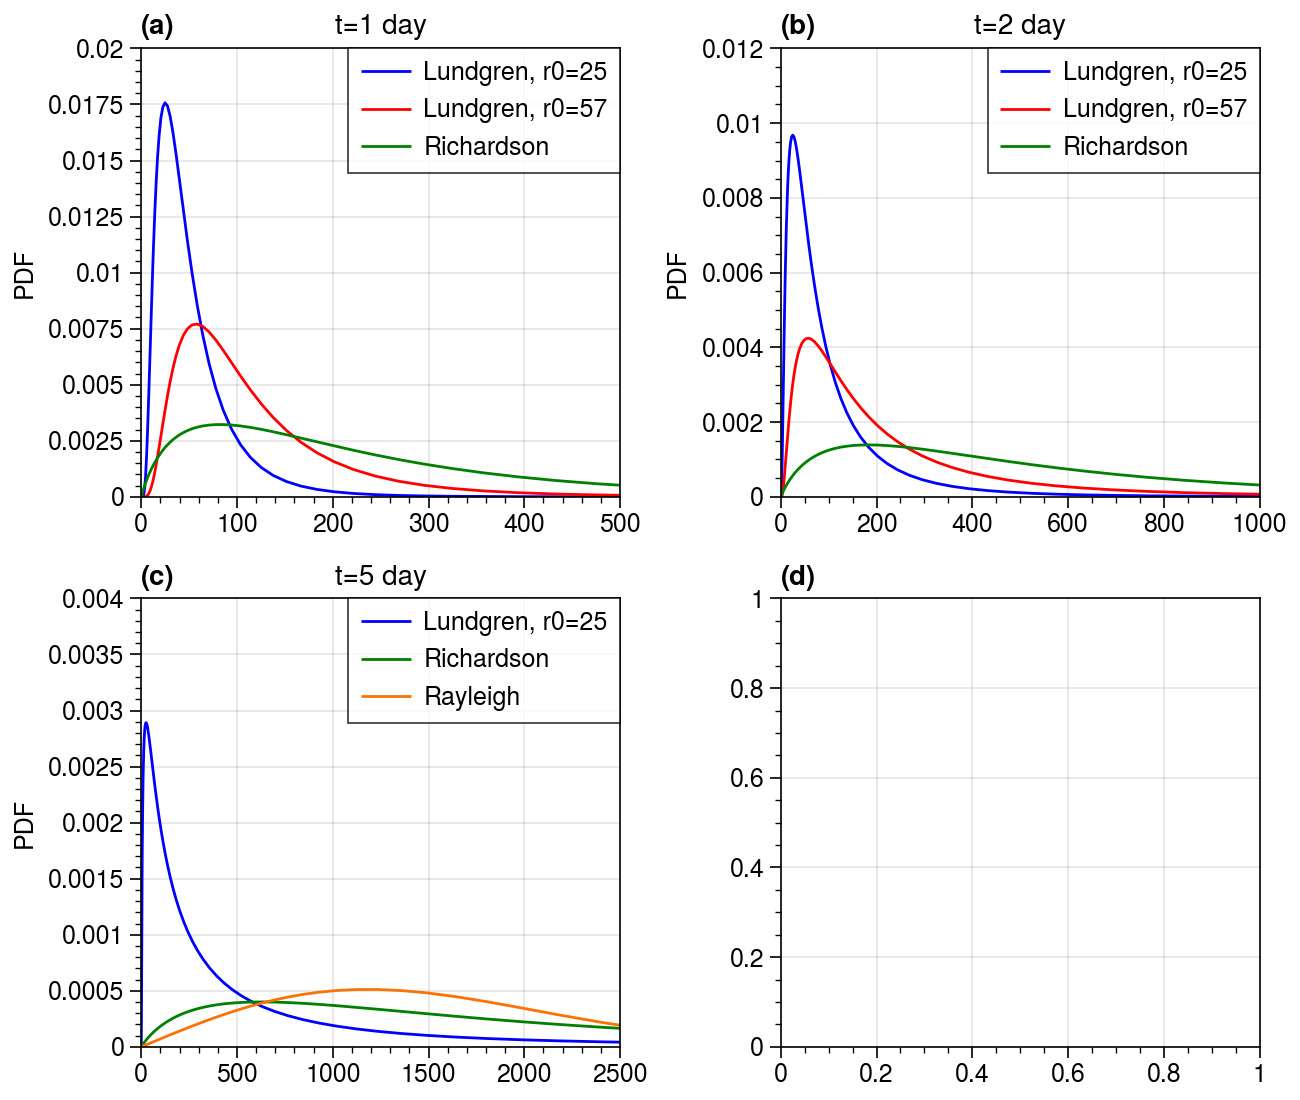

In [85]:
import proplot as pplt
from xdispersion import panel

fig, axes = pplt.subplots(nrows=2, ncols=2, figsize=(6.5, 5.5), facecolor='w',
                          sharex=0, sharey=0)

v1 = {'var':lund2.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=25', 'lw':1, 'color':'b'}
v2 = {'var':lund1.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=57', 'lw':1, 'color':'r'}
v3 = {'var':rich .sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
ax = panel(axes[0,0], [v1,v2,v3],[], title='t=1 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.02], xlim=[0, 500], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund2.sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=25', 'lw':1, 'color':'b'}
v2 = {'var':lund1.sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=57', 'lw':1, 'color':'r'}
v3 = {'var':rich .sel(rtime=2), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
ax = panel(axes[0,1], [v1,v2,v3],[], title='t=2 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.012], xlim=[0, 1000], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund2.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Lundgren, r0=25', 'lw':1, 'color':'b'}
v3 = {'var':rich .sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v4 = {'var':rayl1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[1,0], [v1,v3,v4],[], title='t=5 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 4e-3], xlim=[0, 2500], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
axes.format(abc='(a)')

#### 2.3 Reproduce the Figure 6

In [102]:
lund1 = ana_PDF(rbin, tbin, params={'r0':2.8, 'T':10}, regime='lundgren') * 2 * np.pi * rbin
rich1 = ana_PDF(rbin, tbin, params={'r0':3, 'beta':0.87*2e7**(2/3)/86400}, regime='richardson') * 2 * np.pi * rbin
rayl1 = ana_PDF(rbin, tbin, params={'r0':3, 'k2':1.5e2}, regime='rayleigh-a') * 2 * np.pi * rbin

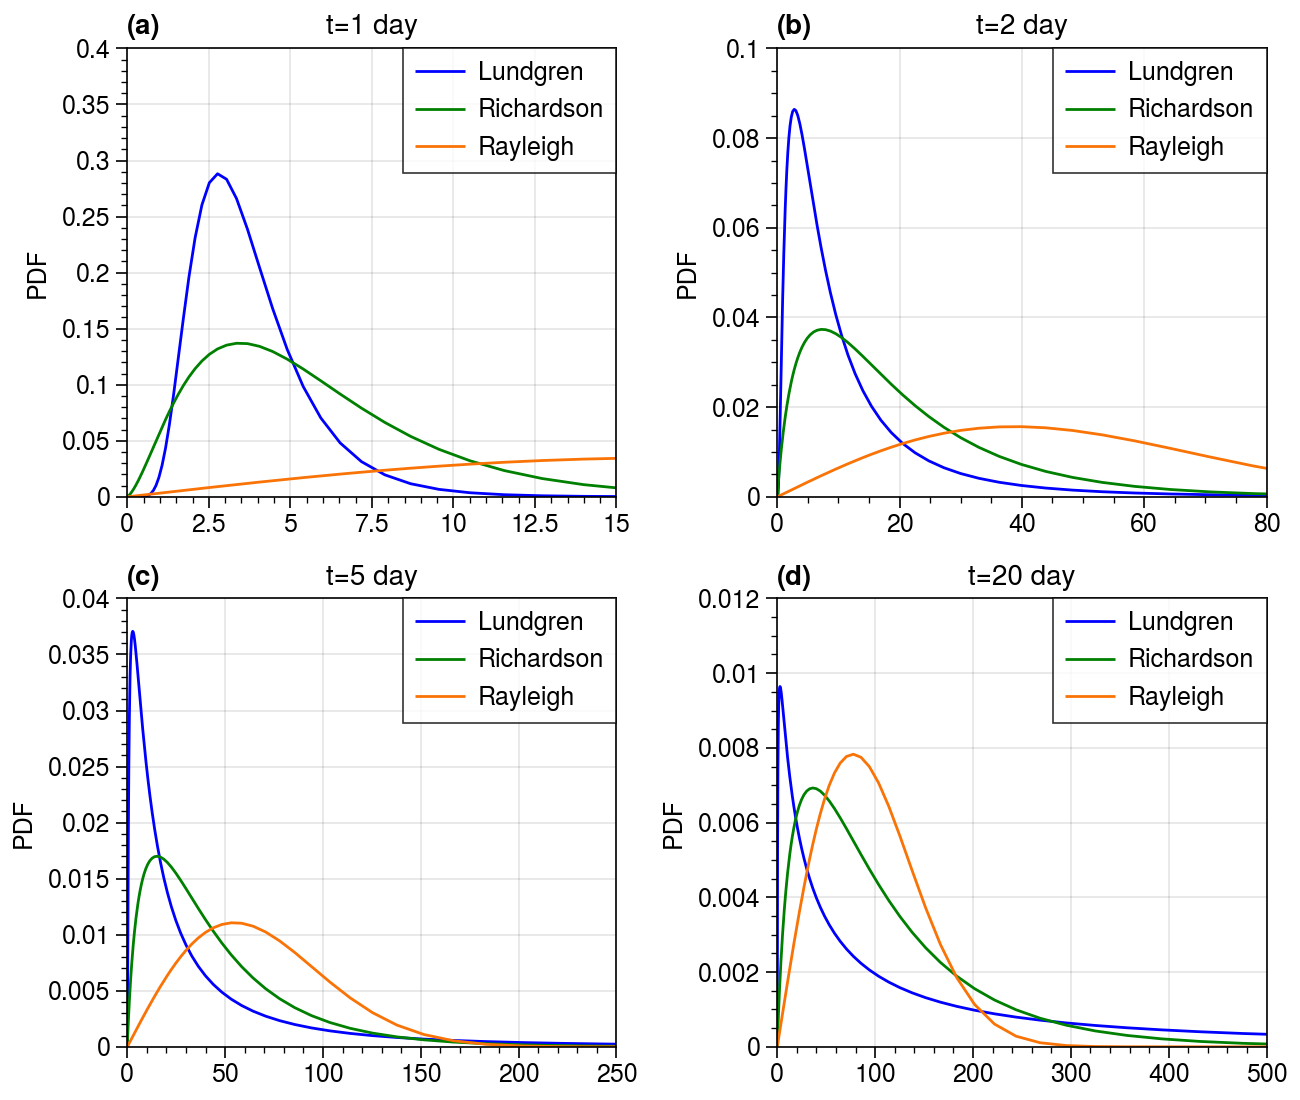

In [103]:
import proplot as pplt
from xdispersion import panel

fig, axes = pplt.subplots(nrows=2, ncols=2, figsize=(6.5, 5.5), facecolor='w',
                          sharex=0, sharey=0)

v1 = {'var':lund1.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Lundgren', 'lw':1, 'color':'b'}
v2 = {'var':rich1.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v3 = {'var':rayl1.sel(rtime=1), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[0,0], [v1,v2,v3],[], title='t=1 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.4], xlim=[0, 15], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Lundgren', 'lw':1, 'color':'b'}
v2 = {'var':rich1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v3 = {'var':rayl1.sel(rtime=5), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[0,1], [v1,v2,v3],[], title='t=2 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.1], xlim=[0, 80], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=10), 'r':rbin, 'method':'plot', 'label':'Lundgren', 'lw':1, 'color':'b'}
v2 = {'var':rich1.sel(rtime=10), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v3 = {'var':rayl1.sel(rtime=10), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[1,0], [v1,v2,v3],[], title='t=5 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.04], xlim=[0, 250], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
v1 = {'var':lund1.sel(rtime=20), 'r':rbin, 'method':'plot', 'label':'Lundgren', 'lw':1, 'color':'b'}
v2 = {'var':rich1.sel(rtime=20), 'r':rbin, 'method':'plot', 'label':'Richardson', 'lw':1, 'color':'g'}
v3 = {'var':rayl1.sel(rtime=20), 'r':rbin, 'method':'plot', 'label':'Rayleigh', 'lw':1, 'color':'orange'}
ax = panel(axes[1,1], [v1,v2,v3],[], title='t=20 day', timebased=True,
           yscale='linear', xscale='linear', ylim=[0, 0.012], xlim=[0, 500], fontsize=10,
           ylabel='PDF', loc='ur', ncols=1)
axes.format(abc='(a)')

### 4. Conclusions

This reproduced almost every aspect of Figs. 3, 4 and 6 in LaCasce (2010).

### References:
- LaCasce, 2010: Relative displacement probability distribution functions from balloons and drifters. *J. Mar. Res.*, **68**, 433-457.